In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Avenir"

In [2]:
results_path = Path(
    "../data/processed/brand_shoe_condition_retention.parquet"
)

retention = pd.read_parquet(results_path)

print("Dataset shape:", retention.shape)
retention.head()

Dataset shape: (135, 14)


,brand_name,shoe_type,Condition 1_median_price,Condition 2_median_price,Condition 3_median_price,Condition 4–5_median_price,Condition 1_listing_count,Condition 2_listing_count,Condition 3_listing_count,Condition 4–5_listing_count,condition_2_retention_percent,condition_3_retention_percent,condition_4_5_retention_percent,condition_pattern
0,ALDO,Boots,46.0,31.0,23.0,12.0,13.0,31.0,52.0,9.0,67.391304,50.000000,NaN,Expected decline pattern
1,ALDO,Pumps,31.0,20.0,20.0,14.0,11.0,41.0,78.0,9.0,64.516129,64.516129,NaN,Expected decline pattern
2,ASICS,Athletic,48.0,31.0,24.0,16.0,42.0,83.0,184.0,20.0,64.583333,50.000000,33.333333,Expected decline pattern
3,Adidas,Athletic,106.0,56.0,33.0,19.0,454.0,309.0,352.0,26.0,52.830189,31.132075,17.924528,Expected decline pattern
4,Adidas,Fashion Sneakers,66.0,51.0,41.0,18.0,203.0,183.0,271.0,25.0,77.272727,62.121212,27.272727,Expected decline pattern


In [3]:
bootstrap_path = Path(
    "../data/processed/brand_shoe_bootstrap_intervals.parquet"
)

bootstrap_results = pd.read_parquet(bootstrap_path)

print("Bootstrap dataset shape:", bootstrap_results.shape)
print(bootstrap_results.columns.tolist())

Bootstrap dataset shape: (133, 13)
['brand_name', 'shoe_type', 'condition_1_count', 'condition_3_count', 'condition_1_median_price', 'condition_1_median_ci_lower', 'condition_1_median_ci_upper', 'condition_3_median_price', 'condition_3_median_ci_lower', 'condition_3_median_ci_upper', 'retention_percent', 'retention_ci_lower', 'retention_ci_upper']


In [4]:
selected_brand = "Nike"
selected_shoe_type = "Athletic"

brand_profile = retention[
    (retention["brand_name"] == selected_brand)
    & (retention["shoe_type"] == selected_shoe_type)
].copy()

brand_profile

,brand_name,shoe_type,Condition 1_median_price,Condition 2_median_price,Condition 3_median_price,Condition 4–5_median_price,Condition 1_listing_count,Condition 2_listing_count,Condition 3_listing_count,Condition 4–5_listing_count,condition_2_retention_percent,condition_3_retention_percent,condition_4_5_retention_percent,condition_pattern
68,Nike,Athletic,62.0,41.0,30.0,19.0,1691.0,1919.0,3751.0,473.0,66.129032,48.387097,30.645161,Expected decline pattern


findfont: Failed to find font weight bold, now using 800.


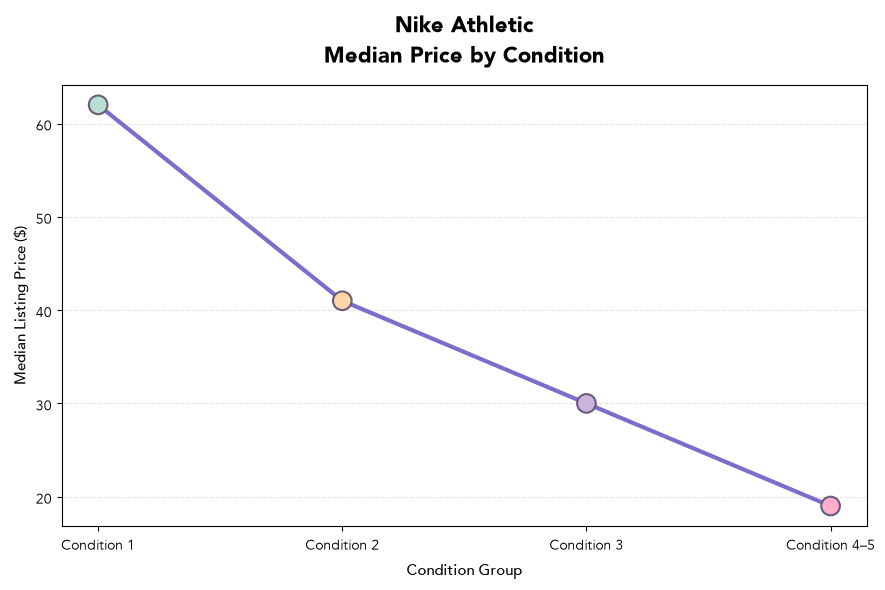

In [5]:
selected_brand = "Nike"
selected_shoe_type = "Athletic"

brand_profile = retention[
    (retention["brand_name"] == selected_brand)
    & (retention["shoe_type"] == selected_shoe_type)
].copy()

condition_labels = [
    "Condition 1",
    "Condition 2",
    "Condition 3",
    "Condition 4–5"
]

median_prices = [
    brand_profile["Condition 1_median_price"].iloc[0],
    brand_profile["Condition 2_median_price"].iloc[0],
    brand_profile["Condition 3_median_price"].iloc[0],
    brand_profile["Condition 4–5_median_price"].iloc[0]
]

condition_colors = [
    "#B8E0D2",  # mint
    "#FFD6A5",  # peach
    "#CDB4DB",  # lavender
    "#FFAFCC"   # pink
]

plt.figure(figsize=(9, 6))

plt.plot(
    condition_labels,
    median_prices,
    marker="o",
    linewidth=3,
    color="#7B6DCC"
)

plt.scatter(
    condition_labels,
    median_prices,
    s=180,
    c=condition_colors,
    edgecolors="#6A5A7B",
    linewidths=1.5,
    zorder=3
)

plt.xlabel(
    "Condition Group",
    fontsize=11,
    fontweight="medium"
)

plt.ylabel(
    "Median Listing Price ($)",
    fontsize=11,
    fontweight="medium"
)

plt.title(
    f"{selected_brand} {selected_shoe_type}\nMedian Price by Condition",
    fontsize=16,
    fontweight="bold",
    pad=16
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

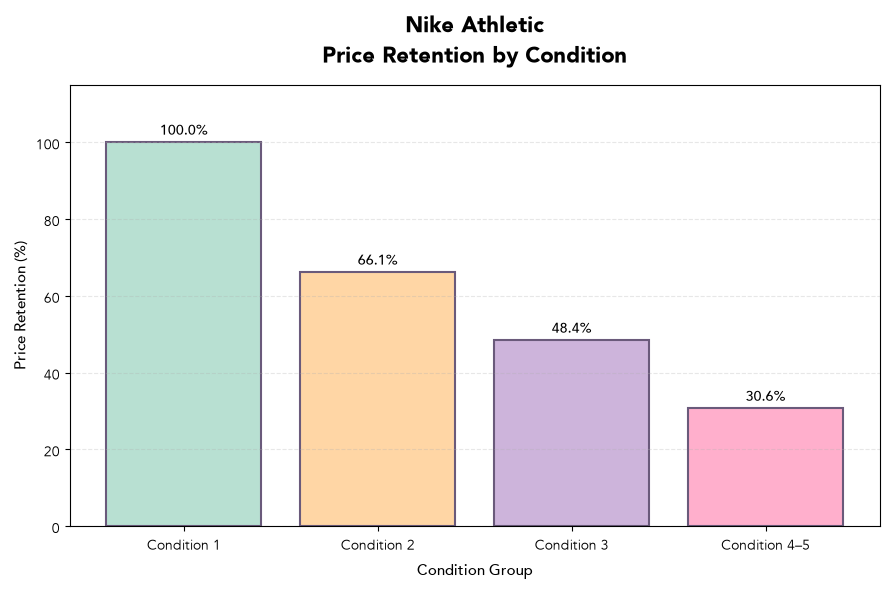

In [6]:
retention_labels = [
    "Condition 1",
    "Condition 2",
    "Condition 3",
    "Condition 4–5"
]

retention_values = [
    100,
    brand_profile["condition_2_retention_percent"].iloc[0],
    brand_profile["condition_3_retention_percent"].iloc[0],
    brand_profile["condition_4_5_retention_percent"].iloc[0]
]

bar_colors = [
    "#B8E0D2",  # mint
    "#FFD6A5",  # peach
    "#CDB4DB",  # lavender
    "#FFAFCC"   # pink
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    retention_labels,
    retention_values,
    color=bar_colors,
    edgecolor="#6A5A7B",
    linewidth=1.5
)

plt.xlabel(
    "Condition Group",
    fontsize=11,
    fontweight="medium"
)

plt.ylabel(
    "Price Retention (%)",
    fontsize=11,
    fontweight="medium"
)

plt.title(
    f"{selected_brand} {selected_shoe_type}\nPrice Retention by Condition",
    fontsize=16,
    fontweight="bold",
    pad=16
)

plt.ylim(0, max(retention_values) + 15)

for bar, value in zip(bars, retention_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{value:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="medium"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

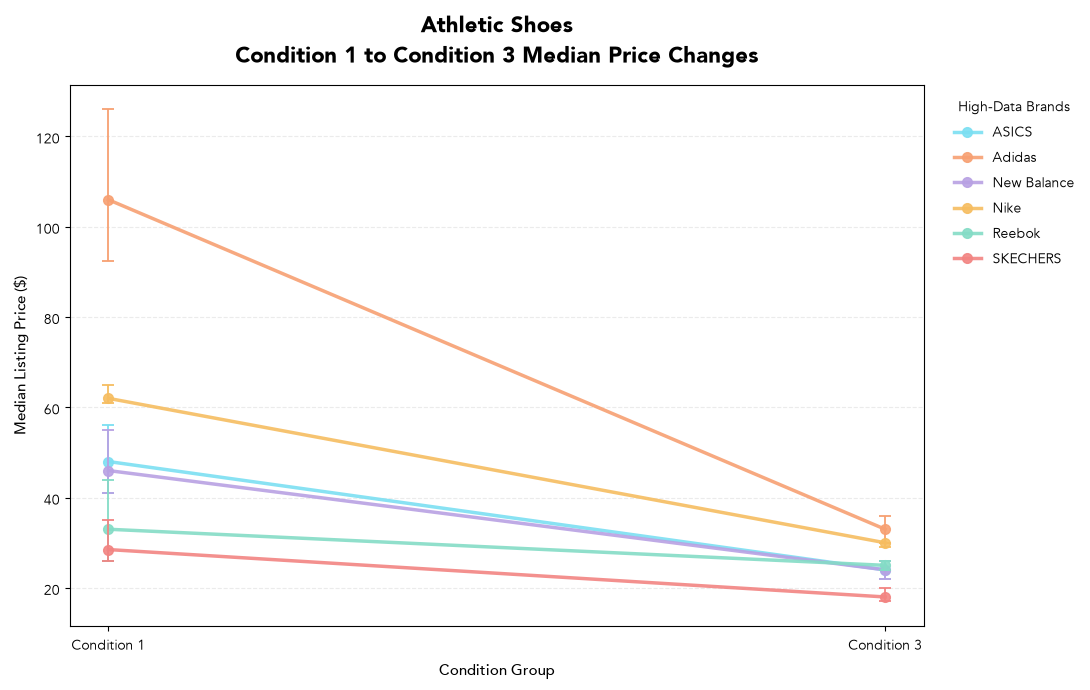

In [7]:
selected_shoe_type = "Athletic"

athletic_profiles = bootstrap_results[
    bootstrap_results["shoe_type"] == selected_shoe_type
].copy()

athletic_profiles["combined_sample_size"] = (
    athletic_profiles["condition_1_count"]
    + athletic_profiles["condition_3_count"]
)

display_brands = (
    athletic_profiles
    .sort_values("combined_sample_size", ascending=False)
    .head(6)
    .sort_values("brand_name")
)

whimsical_colors = [
    "#7BDFF2",
    "#F7A072",
    "#B8A1E3",
    "#F6BD60",
    "#84DCC6",
    "#F28482"
]

x_positions = [0, 1]
x_labels = ["Condition 1", "Condition 3"]

fig, ax = plt.subplots(figsize=(11, 7))

for color, (_, row) in zip(
    whimsical_colors,
    display_brands.iterrows()
):
    median_prices = [
        row["condition_1_median_price"],
        row["condition_3_median_price"]
    ]

    lower_errors = [
        row["condition_1_median_price"]
        - row["condition_1_median_ci_lower"],
        row["condition_3_median_price"]
        - row["condition_3_median_ci_lower"]
    ]

    upper_errors = [
        row["condition_1_median_ci_upper"]
        - row["condition_1_median_price"],
        row["condition_3_median_ci_upper"]
        - row["condition_3_median_price"]
    ]

    warning = " ⚠" if row["retention_percent"] > 100 else ""

    ax.plot(
        x_positions,
        median_prices,
        linewidth=2.5,
        marker="o",
        markersize=7,
        color=color,
        alpha=0.9,
        label=f"{row['brand_name']}{warning}"
    )

    ax.errorbar(
        x_positions,
        median_prices,
        yerr=[lower_errors, upper_errors],
        fmt="none",
        ecolor=color,
        elinewidth=1.3,
        capsize=4,
        capthick=1.3
    )

ax.set_xticks(
    x_positions,
    x_labels
)

ax.set_xlabel(
    "Condition Group",
    fontsize=11,
    fontweight="medium"
)

ax.set_ylabel(
    "Median Listing Price ($)",
    fontsize=11,
    fontweight="medium"
)

ax.set_title(
    f"{selected_shoe_type} Shoes\n"
    "Condition 1 to Condition 3 Median Price Changes",
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.legend(
    title="High-Data Brands",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

In [8]:
from pathlib import Path

chart_output_dir = Path("../outputs/charts")
chart_output_dir.mkdir(parents=True, exist_ok=True)

shoe_types = [
    "Boots",
    "Sandals",
    "Athletic",
    "Fashion Sneakers",
    "Pumps",
    "Flats",
    "Loafers & Slip-Ons"
]

whimsical_colors = [
    "#7BDFF2",
    "#F7A072",
    "#B8A1E3",
    "#F6BD60",
    "#84DCC6",
    "#F28482",
    "#A8DADC",
    "#CDB4DB"
]

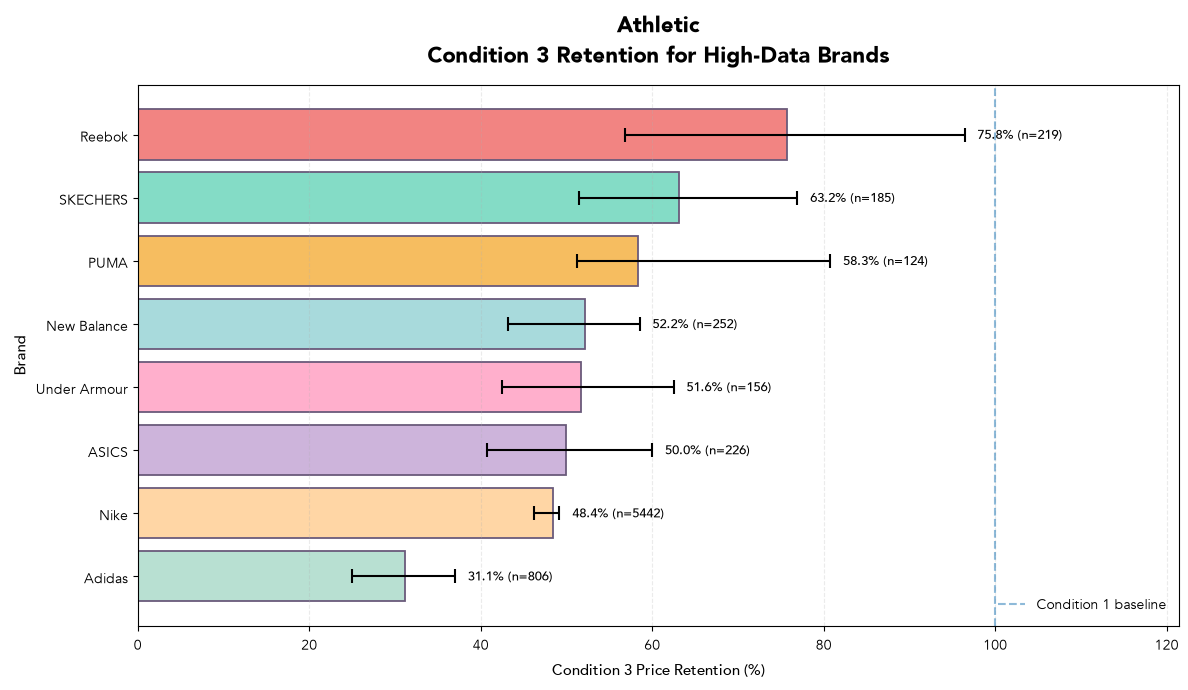

In [16]:
selected_shoe_type = "Athletic"

athletic_profiles = bootstrap_results[
    bootstrap_results["shoe_type"] == selected_shoe_type
].copy()

athletic_profiles["combined_sample_size"] = (
    athletic_profiles["condition_1_count"]
    + athletic_profiles["condition_3_count"]
)

display_brands = (
    athletic_profiles
    .sort_values("combined_sample_size", ascending=False)
    .head(8)
    .sort_values("retention_percent")
)

whimsical_colors = [
    "#B8E0D2",
    "#FFD6A5",
    "#CDB4DB",
    "#FFAFCC",
    "#A8DADC",
    "#F6BD60",
    "#84DCC6",
    "#F28482"
]

lower_errors = (
    display_brands["retention_percent"]
    - display_brands["retention_ci_lower"]
)

upper_errors = (
    display_brands["retention_ci_upper"]
    - display_brands["retention_percent"]
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    display_brands["brand_name"],
    display_brands["retention_percent"],
    color=whimsical_colors[:len(display_brands)],
    edgecolor="#6A5A7B",
    linewidth=1.3,
    xerr=[lower_errors, upper_errors],
    capsize=5,
    error_kw={
        "elinewidth": 1.5,
        "capthick": 1.5
    }
)

plt.xlabel(
    "Condition 3 Price Retention (%)",
    fontsize=11,
    fontweight="medium"
)

plt.ylabel(
    "Brand",
    fontsize=11,
    fontweight="medium"
)

plt.title(
    f"{selected_shoe_type}\n"
    "Condition 3 Retention for High-Data Brands",
    fontsize=16,
    fontweight="bold",
    pad=16
)

max_value = display_brands["retention_ci_upper"].max()

plt.xlim(
    0,
    max(110, max_value + 25)
)

plt.axvline(
    100,
    linestyle="--",
    linewidth=1.5,
    alpha=0.5,
    label="Condition 1 baseline"
)

for bar, (_, row) in zip(
    bars,
    display_brands.iterrows()
):
    value = row["retention_percent"]
    total_sample = row["combined_sample_size"]

    label = (
        f"{value:.1f}% "
        f"(n={int(total_sample)})"
    )

    if value > 100:
        label += " ⚠"

    plt.text(
        row["retention_ci_upper"] + 1.5,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=9,
        fontweight="medium"
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.legend(
    frameon=False,
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [13]:
def plot_condition_price_change(
    bootstrap_data,
    shoe_type,
    top_n=6,
    save_chart=True
):
    profiles = bootstrap_data[
        bootstrap_data["shoe_type"] == shoe_type
    ].copy()

    profiles["combined_sample_size"] = (
        profiles["condition_1_count"]
        + profiles["condition_3_count"]
    )

    display_brands = (
        profiles
        .sort_values("combined_sample_size", ascending=False)
        .head(top_n)
        .sort_values("brand_name")
    )

    if display_brands.empty:
        print(f"No qualifying data for {shoe_type}.")
        return

    colors = whimsical_colors[:len(display_brands)]

    x_positions = [0, 1]
    x_labels = ["Condition 1", "Condition 3"]

    fig, ax = plt.subplots(figsize=(11, 7))

    for color, (_, row) in zip(
        colors,
        display_brands.iterrows()
    ):
        median_prices = [
            row["condition_1_median_price"],
            row["condition_3_median_price"]
        ]

        lower_errors = [
            row["condition_1_median_price"]
            - row["condition_1_median_ci_lower"],

            row["condition_3_median_price"]
            - row["condition_3_median_ci_lower"]
        ]

        upper_errors = [
            row["condition_1_median_ci_upper"]
            - row["condition_1_median_price"],

            row["condition_3_median_ci_upper"]
            - row["condition_3_median_price"]
        ]

        warning = (
            " ⚠"
            if row["retention_percent"] > 100
            else ""
        )

        ax.plot(
            x_positions,
            median_prices,
            linewidth=2.5,
            marker="o",
            markersize=7,
            color=color,
            alpha=0.9,
            label=f"{row['brand_name']}{warning}"
        )

        ax.errorbar(
            x_positions,
            median_prices,
            yerr=[lower_errors, upper_errors],
            fmt="none",
            ecolor=color,
            elinewidth=1.3,
            capsize=4,
            capthick=1.3
        )

    ax.set_xticks(
        x_positions,
        x_labels
    )

    ax.set_xlabel(
        "Condition Group",
        fontsize=11,
        fontweight="medium"
    )

    ax.set_ylabel(
        "Median Listing Price ($)",
        fontsize=11,
        fontweight="medium"
    )

    ax.set_title(
        f"{shoe_type}\n"
        "Condition 1 to Condition 3 Median Price Changes",
        fontsize=16,
        fontweight="bold",
        pad=16
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.legend(
        title="High-Data Brands",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    plt.tight_layout()

    if save_chart:
        safe_name = (
            shoe_type
            .lower()
            .replace(" ", "_")
            .replace("&", "and")
            .replace("/", "_")
        )

        plt.savefig(
            chart_output_dir
            / f"{safe_name}_condition_1_to_3_prices.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

In [14]:
def plot_condition_3_retention(
    bootstrap_data,
    shoe_type,
    top_n=8,
    save_chart=True
):
    profiles = bootstrap_data[
        bootstrap_data["shoe_type"] == shoe_type
    ].copy()

    profiles["combined_sample_size"] = (
        profiles["condition_1_count"]
        + profiles["condition_3_count"]
    )

    display_brands = (
        profiles
        .sort_values("combined_sample_size", ascending=False)
        .head(top_n)
        .sort_values("retention_percent")
    )

    if display_brands.empty:
        print(f"No qualifying data for {shoe_type}.")
        return

    colors = whimsical_colors[:len(display_brands)]

    lower_errors = (
        display_brands["retention_percent"]
        - display_brands["retention_ci_lower"]
    )

    upper_errors = (
        display_brands["retention_ci_upper"]
        - display_brands["retention_percent"]
    )

    fig, ax = plt.subplots(figsize=(12, 7))

    bars = ax.barh(
        display_brands["brand_name"],
        display_brands["retention_percent"],
        color=colors,
        edgecolor="#6A5A7B",
        linewidth=1.3,
        xerr=[lower_errors, upper_errors],
        capsize=5,
        error_kw={
            "elinewidth": 1.5,
            "capthick": 1.5
        }
    )

    ax.set_xlabel(
        "Condition 3 Price Retention (%)",
        fontsize=11,
        fontweight="medium"
    )

    ax.set_ylabel(
        "Brand",
        fontsize=11,
        fontweight="medium"
    )

    ax.set_title(
        f"{shoe_type}\n"
        "Condition 3 Retention for High-Data Brands",
        fontsize=16,
        fontweight="bold",
        pad=16
    )

    max_value = display_brands["retention_ci_upper"].max()

    ax.set_xlim(
        0,
        max(110, max_value + 25)
    )

    ax.axvline(
        100,
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        label="Condition 1 baseline"
    )

    for bar, (_, row) in zip(
        bars,
        display_brands.iterrows()
    ):
        warning = (
            " ⚠"
            if row["retention_percent"] > 100
            else ""
        )

        label = (
            f"{row['retention_percent']:.1f}% "
            f"(n={int(row['combined_sample_size'])})"
            f"{warning}"
        )

        ax.text(
            row["retention_ci_upper"] + 1.5,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            fontsize=9,
            fontweight="medium"
        )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25
    )

    ax.legend(
        frameon=False,
        loc="lower right"
    )

    plt.tight_layout()

    if save_chart:
        safe_name = (
            shoe_type
            .lower()
            .replace(" ", "_")
            .replace("&", "and")
            .replace("/", "_")
        )

        plt.savefig(
            chart_output_dir
            / f"{safe_name}_condition_3_retention.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

Creating charts for: Boots


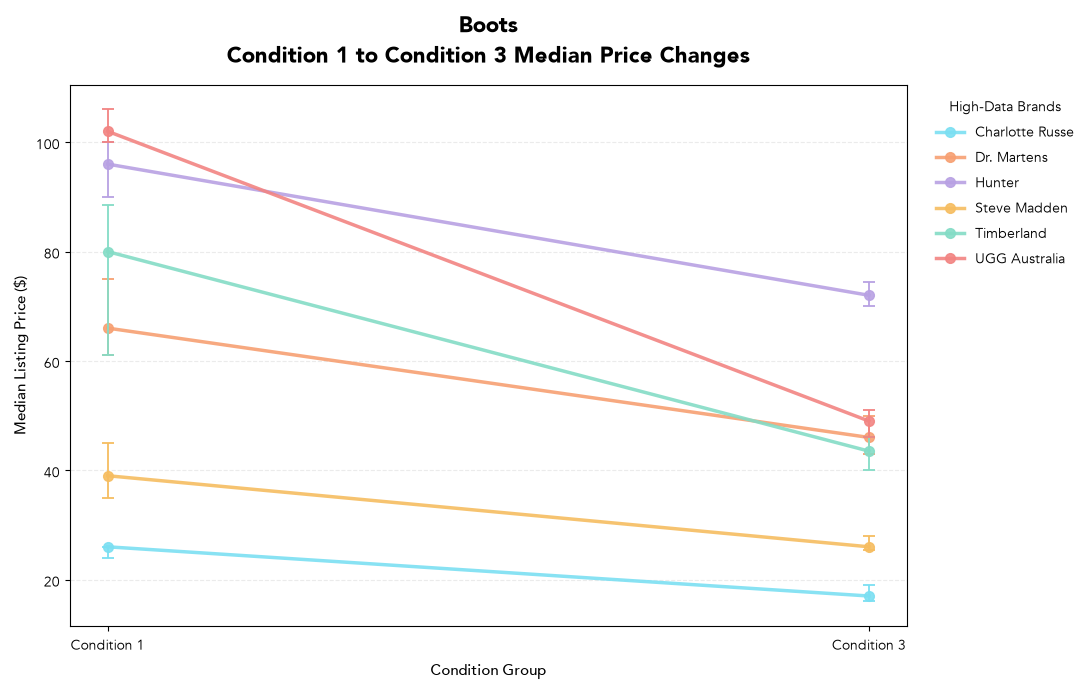

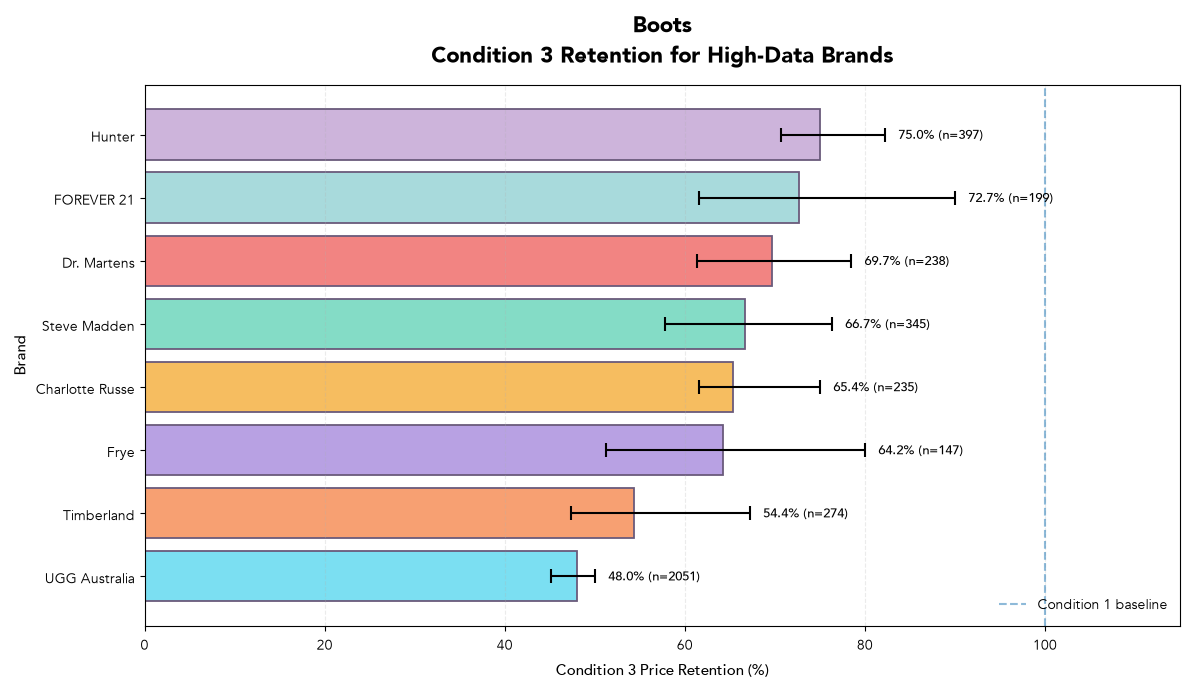

Creating charts for: Sandals


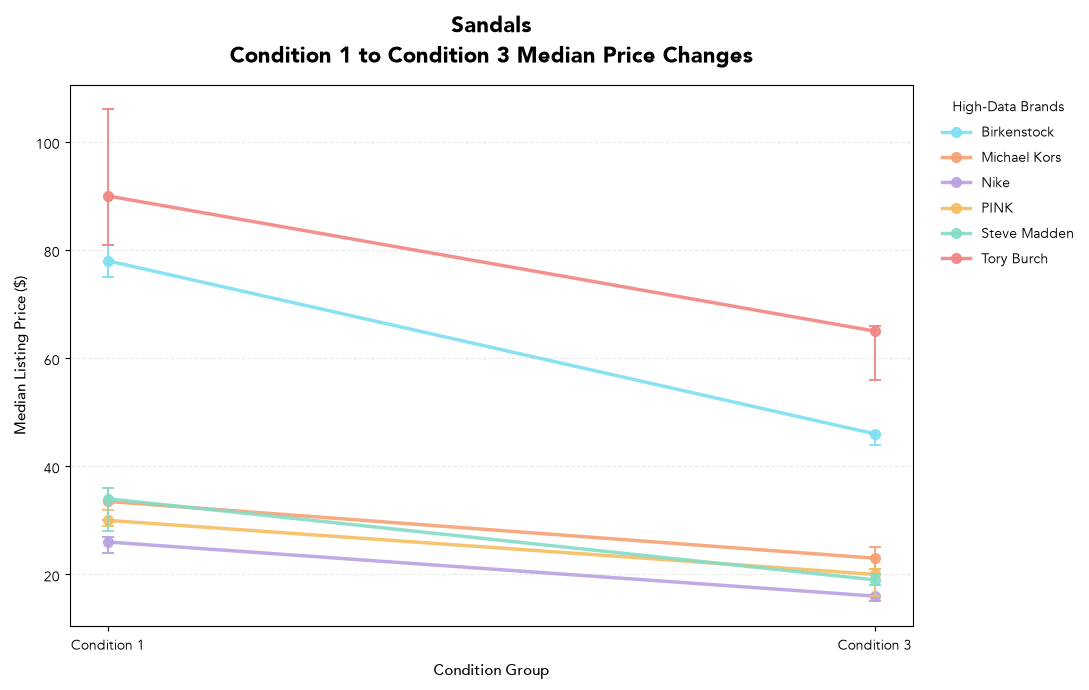

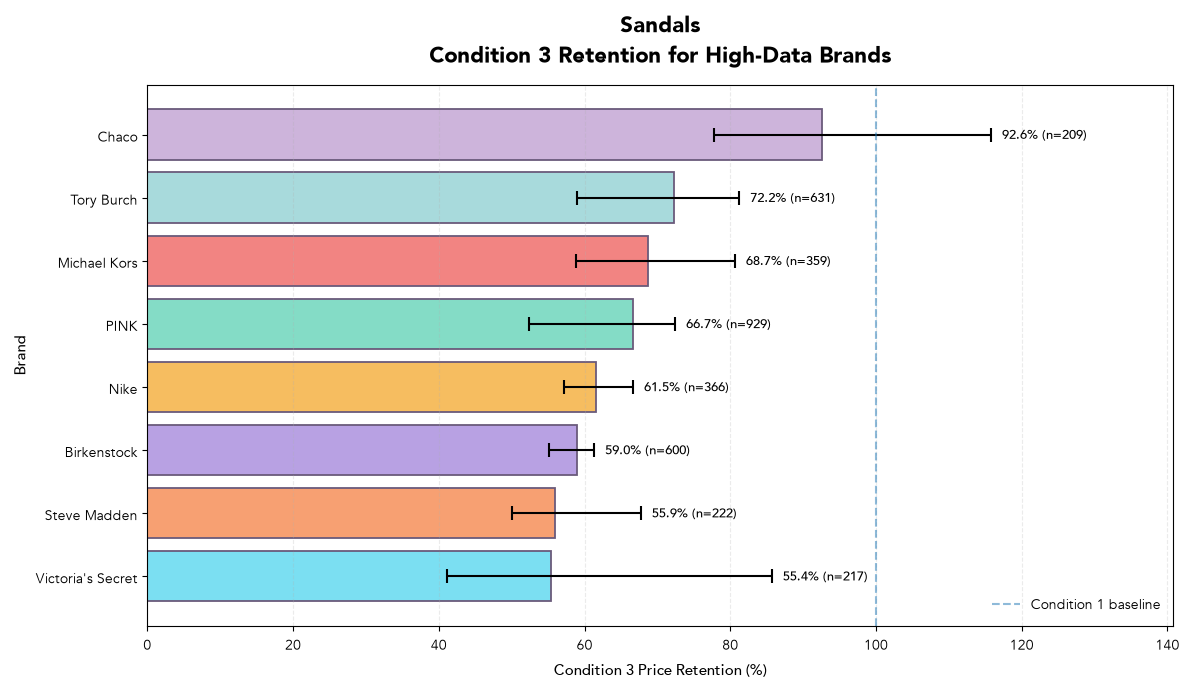

Creating charts for: Athletic


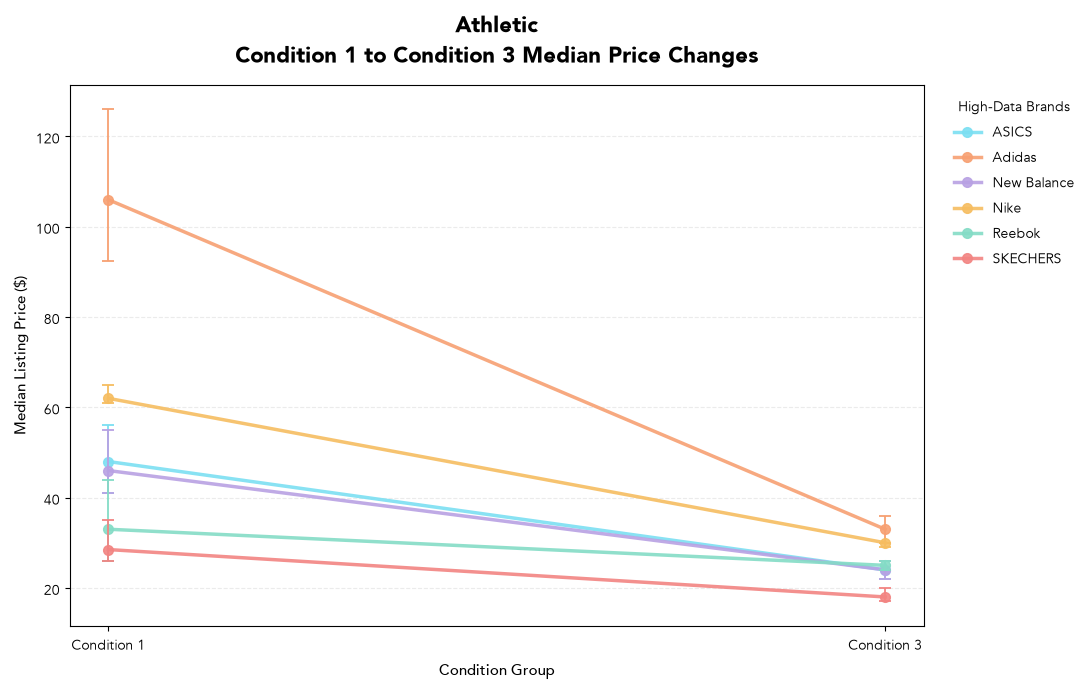

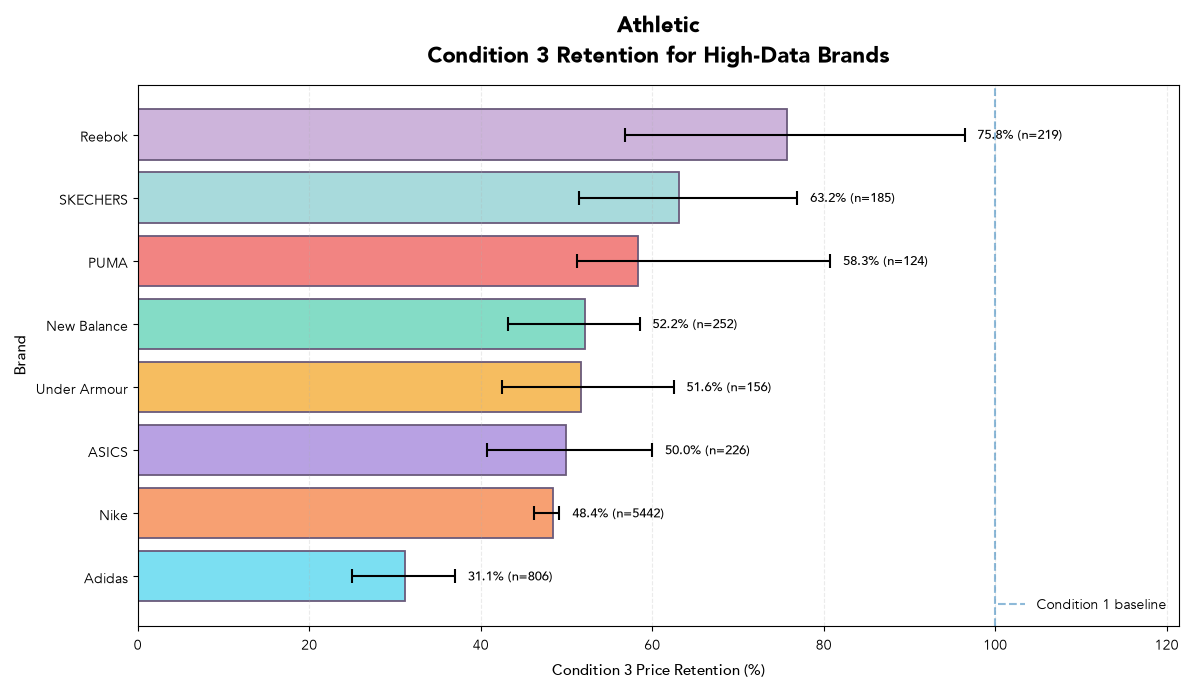

Creating charts for: Fashion Sneakers


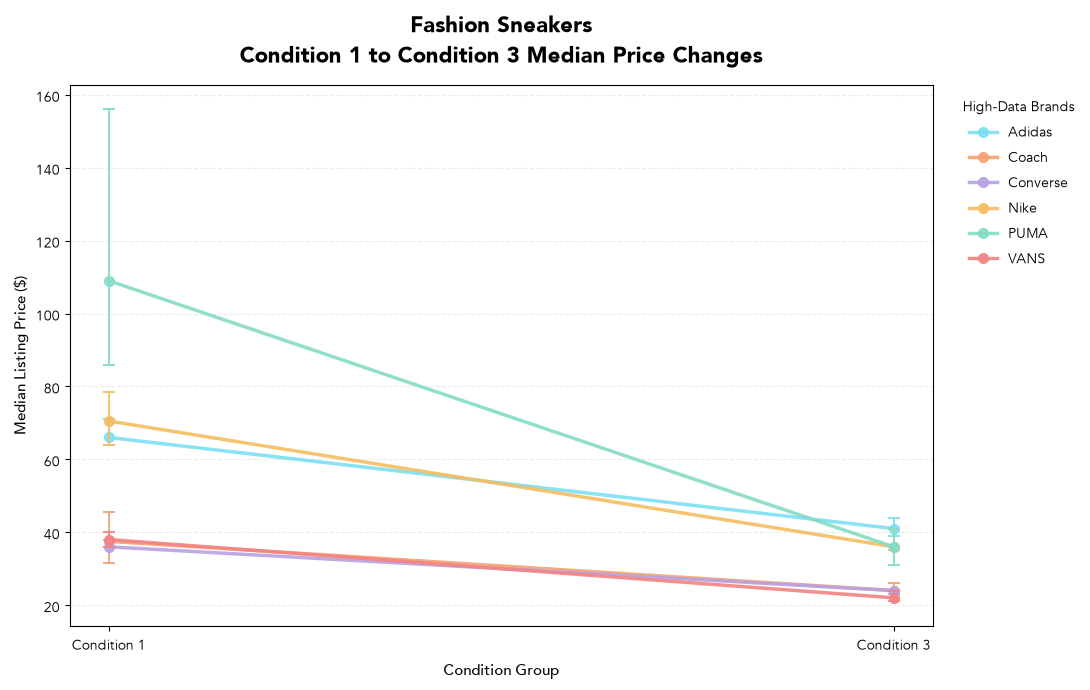

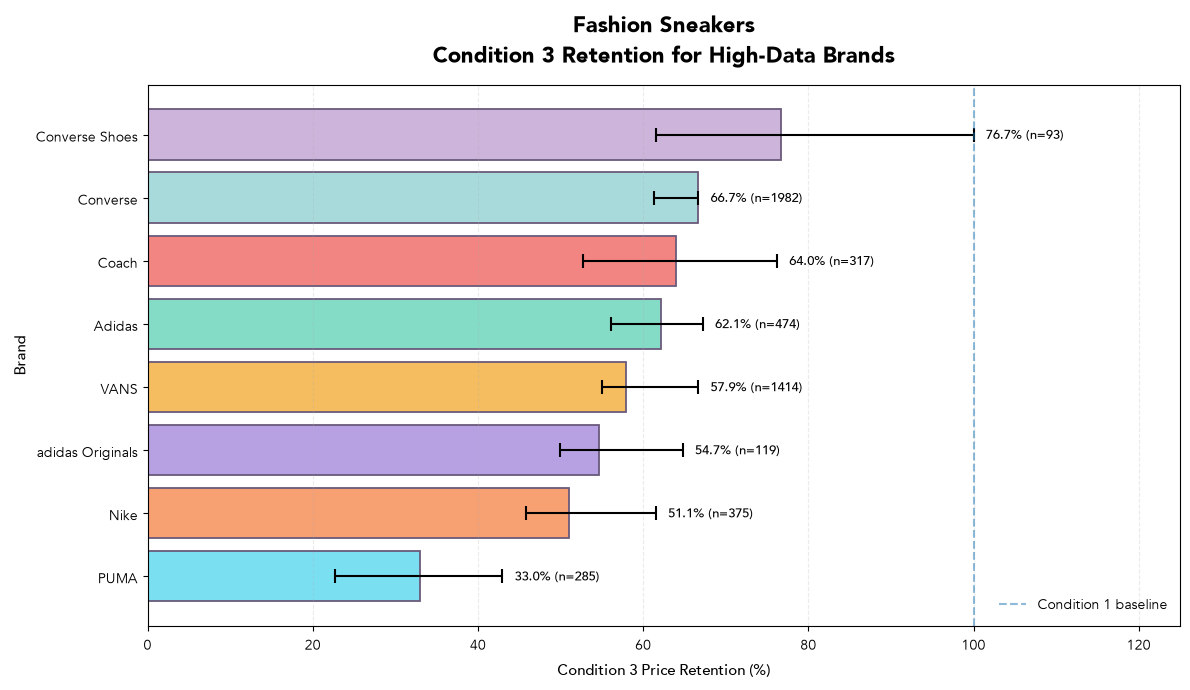

Creating charts for: Pumps


/var/folders/8h/r93g30d90yv0rw4wtxz162k40000gn/T/ipykernel_47230/2801895088.py:125: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Avenir.
  plt.tight_layout()
/var/folders/8h/r93g30d90yv0rw4wtxz162k40000gn/T/ipykernel_47230/2801895088.py:136: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Avenir.
  plt.savefig(
/Users/ipekcoskunuzer/Desktop/mercari-shoe-resale-analysis/.venv-1/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Avenir.
  fig.canvas.print_figure(bytes_io, **kw)


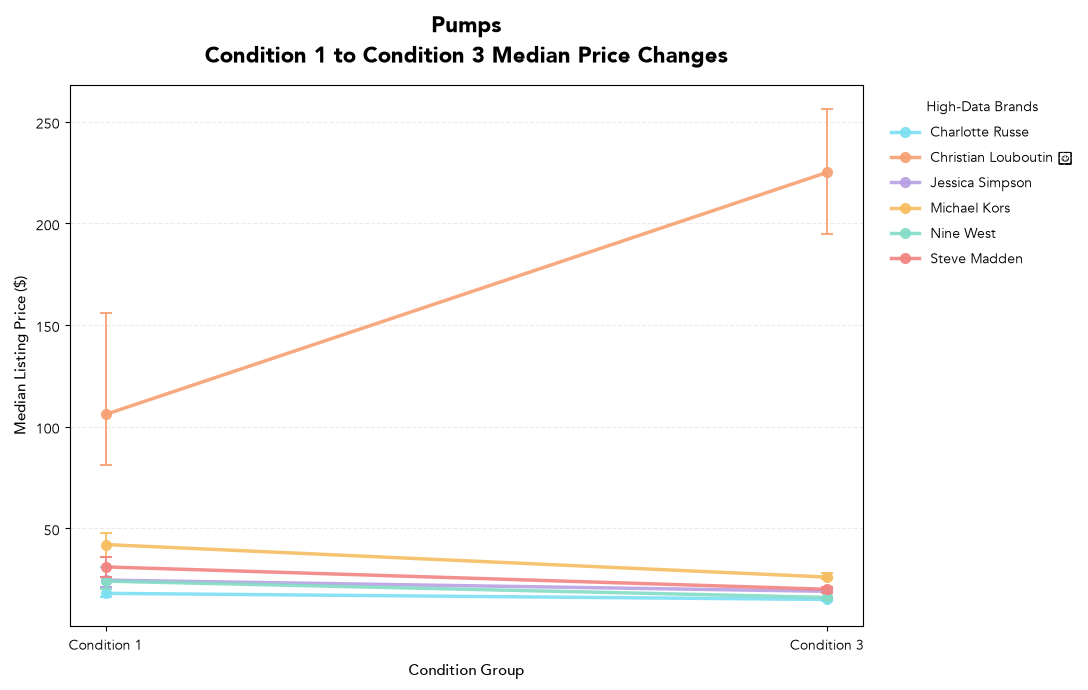

/var/folders/8h/r93g30d90yv0rw4wtxz162k40000gn/T/ipykernel_47230/27443041.py:126: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Avenir.
  plt.tight_layout()
/var/folders/8h/r93g30d90yv0rw4wtxz162k40000gn/T/ipykernel_47230/27443041.py:137: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Avenir.
  plt.savefig(
/Users/ipekcoskunuzer/Desktop/mercari-shoe-resale-analysis/.venv-1/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Avenir.
  fig.canvas.print_figure(bytes_io, **kw)


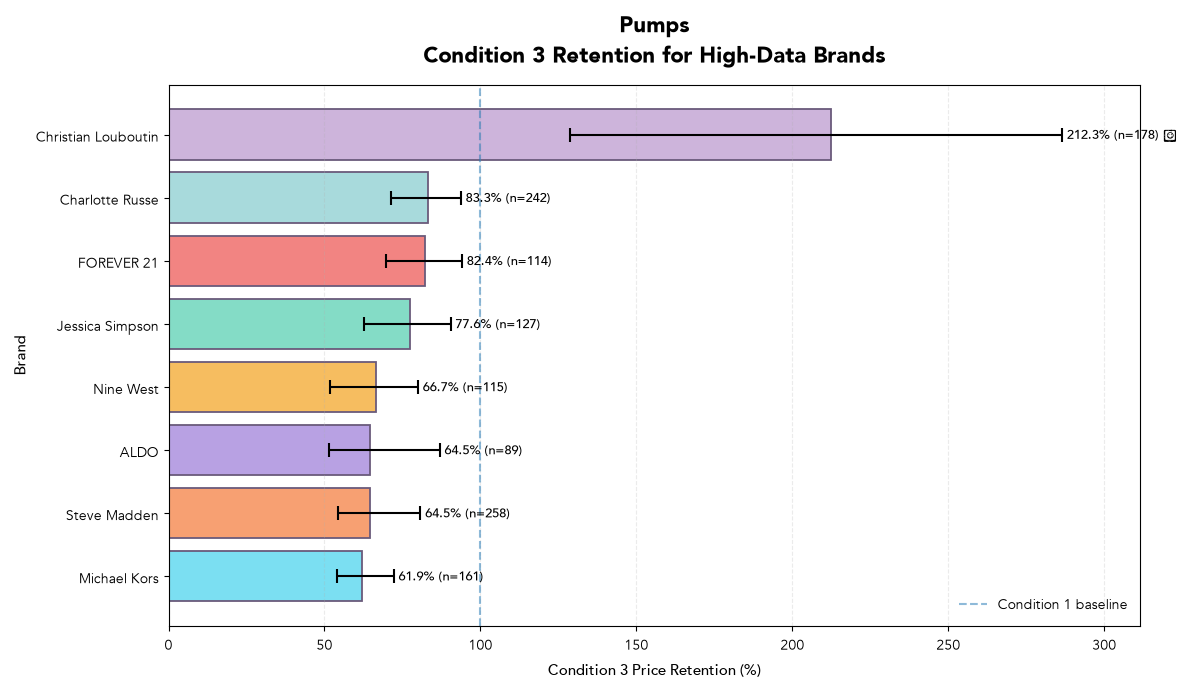

Creating charts for: Flats


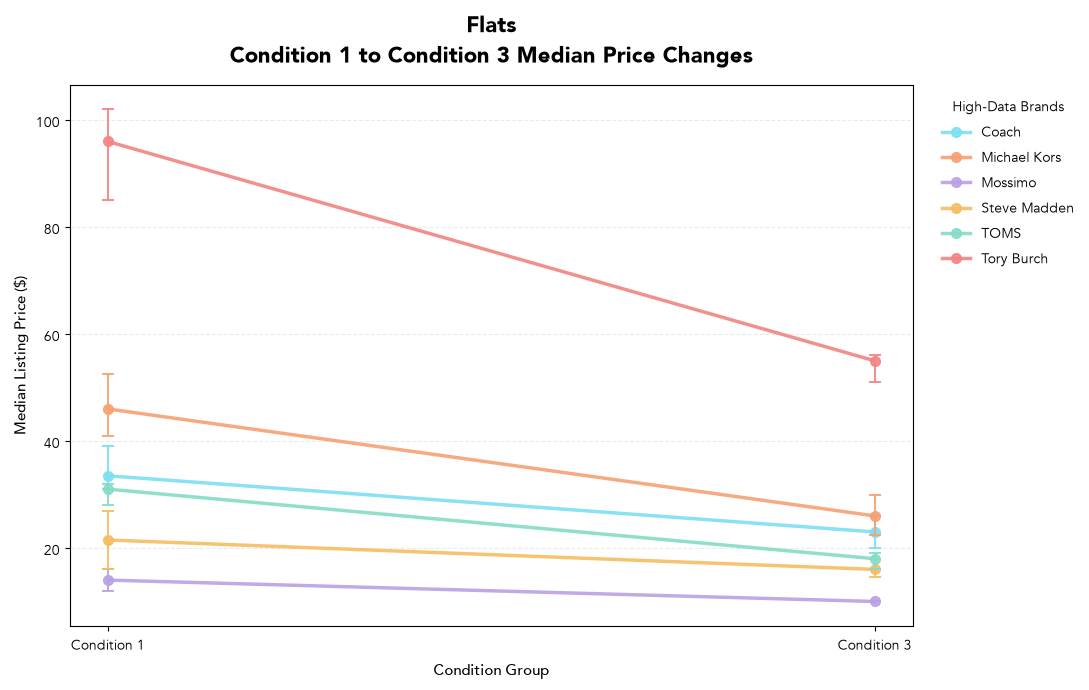

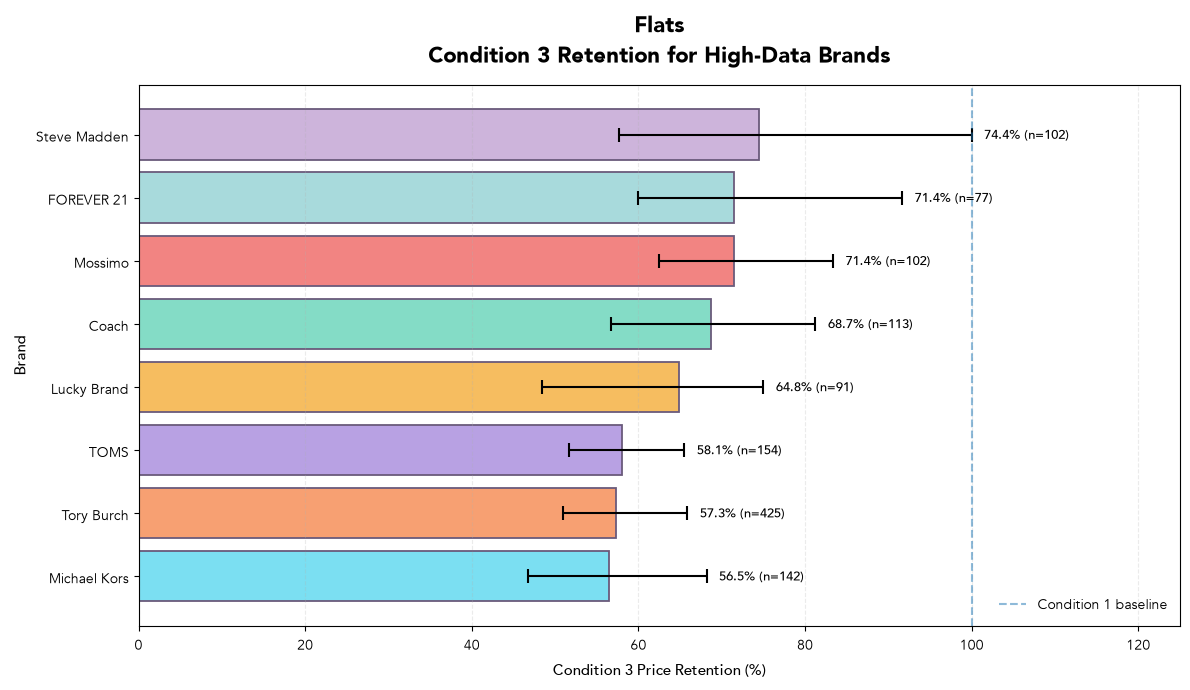

Creating charts for: Loafers & Slip-Ons


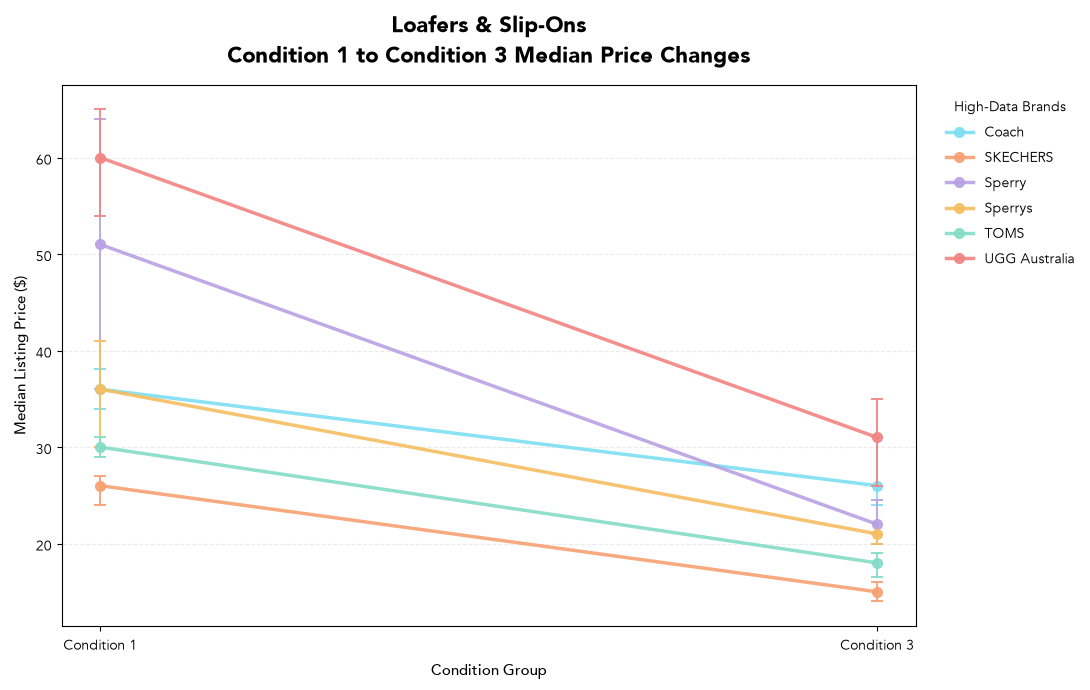

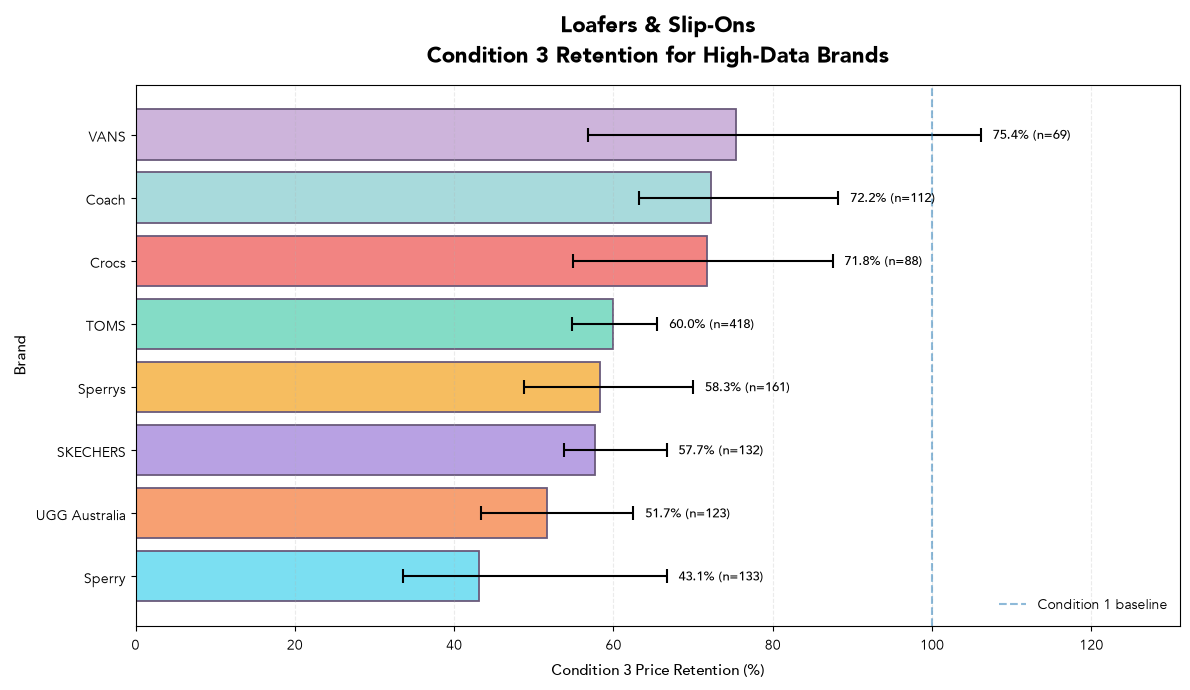

In [11]:
for shoe_type in shoe_types:
    print(f"Creating charts for: {shoe_type}")

    plot_condition_price_change(
        bootstrap_results,
        shoe_type
    )

    plot_condition_3_retention(
        bootstrap_results,
        shoe_type
    )